

This notebook analyzes the merged BLS Employment Projections + JOLTS + Anthropic Economic Index + **O*NET Skills** dataset to answer:

**(a)** What is the likelihood of someone with a given job being unemployed in 2034?
- Predicted probability of decline per occupation
- Performance across probability cut-off thresholds

**(b)** What job characteristics are associated with employment growth vs decline? *Exploratory data analysis with logistic and linear regression.*

**(c)** [NEW] What individual O*NET skills correlate most strongly with projected decline and with AI exposure? Can combinations of skills (via PCA) predict employment decline?

---

## Important framing note

The dataset contains projected employment levels per occupation, not worker-level unemployment data. Strictly speaking, the probability that a worker in occupation X is unemployed in 2034 requires longitudinal microdata (e.g., CPS), which is not in this file.

What can be modeled from this data is the probability that an occupation will see a projected employment decline (2034 employment < 2024 employment). This serves as a defensible proxy: occupations projected to shrink are the ones most likely to produce displaced workers, even if individual unemployment outcomes will vary substantially within any given occupation. We report this as P(Decline) rather than P(Unemployment) throughout.


### 1. Setup and data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_curve)
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
df = pd.read_csv('data/Employment_Projections_with_JOLTS_AI_and_Skills.csv')
print(f'Rows: {len(df)}, Columns: {df.shape[1]}')
df.head(2)

Rows: 832, Columns: 54


,Occupation Title,Occupation Code,Employment 2024,Employment 2034,"Employment Change, 2024-2034","Employment Percent Change, 2024-2034","Occupational Openings, 2024-2034 Annual Average",Median Annual Wage 2024,Typical Entry-Level Education,JOLTS Industry (mapped),Mapping Confidence,JOLTS Hires Rate 2024 (%),JOLTS Job Openings Rate 2024 (%),JOLTS Quits Rate 2024 (%),SOC Major Group (AI exposure),AI Theoretical Exposure (%),AI Observed Exposure — Occupation (%),AI Displacement Risk Tier,Mapping Notes,Active Learning,Active Listening,Complex Problem Solving,Coordination,Critical Thinking,Equipment Maintenance,Equipment Selection,Installation,Instructing,Judgment and Decision Making,Learning Strategies,Management of Financial Resources,Management of Material Resources,Management of Personnel Resources,Mathematics,Monitoring,Negotiation,Operation and Control,Operations Analysis,Operations Monitoring,Persuasion,Programming,Quality Control Analysis,Reading Comprehension,Repairing,Science,Service Orientation,Social Perceptiveness,Speaking,Systems Analysis,Systems Evaluation,Technology Design,Time Management,Troubleshooting,Writing
0,Accountants and auditors * Account Auditor*...,13-2011,"1,579.80","1,652.60",72.8,4.6,124.2,"81,680",Bachelor's degree,Professional and business services,low,4.4,5.5,2.4,Business & Financial Operations,94.3,28.4,Very high (top-10 most exposed),Business/Financial Ops — cross-industry,3.12,3.75,3.38,3.25,3.75,1.0,1.25,1.12,2.75,3.50,2.75,2.25,1.88,2.75,3.25,3.38,2.88,1.38,1.62,1.75,3.0,2.0,1.88,3.88,1.0,1.25,3.12,3.12,3.75,2.88,2.88,1.75,3.12,1.0,3.50
1,Actors * Actor Understudy* Actress* Dramati...,27-2011,57,57.1,0.2,0.3,6.3,NaN,"Some college, no degree","Arts, entertainment, and recreation",medium,6.3,5.3,2.8,"Arts, Design, Entertainment & Media",83.7,19.2,High,Arts/Design/Entertainment/Media — mixed with Info,2.62,3.75,2.88,2.88,3.00,1.0,1.00,1.00,2.75,2.88,2.75,1.00,1.00,2.38,1.00,3.00,2.50,1.00,1.75,1.25,2.5,1.0,1.00,3.88,1.0,1.50,2.12,3.75,3.88,2.00,2.00,1.25,3.00,1.0,2.88


### 2. Data cleaning

The source CSV has thousand-separator commas in several numeric columns and `N/A` literals in the wage column. Coerce these to proper numeric types before doing any math.

In [3]:
def to_num(s):
    if pd.isna(s):
        return np.nan
    return pd.to_numeric(str(s).replace(',', '').replace('N/A', ''), errors='coerce')

for col in ['Employment 2024', 'Employment 2034', 'Median Annual Wage 2024']:
    df[col] = df[col].apply(to_num)

# Strip the alias list from the occupation title
df['Occupation Title (clean)'] = df['Occupation Title'].str.split(r'\s{2,}\*', n=1).str[0]

print('Null counts after coercion:')
print(df[['Employment 2024', 'Employment 2034', 'Median Annual Wage 2024']].isna().sum())

Null counts after coercion:
Employment 2024             0
Employment 2034             0
Median Annual Wage 2024    23
dtype: int64


### 3. Define the target

We use **two related targets**:

- **Binary**: `Will Decline` = 1 if projected 2034 employment is below 2024 employment (logistic regression target)
- **Continuous**: `Employment Percent Change, 2024-2034` (linear regression target)

These let us answer the two parts of the question with appropriate models.

In [4]:
df['Will Decline'] = (df['Employment Percent Change, 2024-2034'] < 0).astype(int)

n_decline = df['Will Decline'].sum()
n_total = len(df)
print(f'Declining occupations: {n_decline} / {n_total} ({n_decline/n_total*100:.1f}%)')

df['Employment Percent Change, 2024-2034'].describe()

Declining occupations: 244 / 832 (29.3%)


count    832.000000
mean       1.744712
std        7.629244
min      -36.100000
25%       -1.100000
50%        2.500000
75%        5.000000
max       49.900000
Name: Employment Percent Change, 2024-2034, dtype: float64

### 4. Feature engineering

Three transformations:

1. **Ordinal encoding** for education level and AI risk tier (preserves natural ordering instead of one-hot)
2. **Log transformation** for wage and employment (both heavily right-skewed)
3. **Mean imputation for AI exposures**: the "Very low" tier occupations have no published exposure values from Anthropic — fill with 0, which reflects that observed Claude usage on those occupations is effectively zero

In [5]:
EDU_ORDER = {
    'No formal educational credential':   0,
    'High school diploma or equivalent':  1,
    'Some college, no degree':            2,
    'Postsecondary nondegree award':      2,
    "Associate's degree":                 3,
    "Bachelor's degree":                  4,
    "Master's degree":                    5,
    'Doctoral or professional degree':    6,
}
df['Education Level'] = df['Typical Entry-Level Education'].map(EDU_ORDER)

RISK_ORDER = {
    'Very low': 0, 'Low': 1, 'Moderate': 2, 'High': 3,
    'Very high': 4, 'Very high (top-10 most exposed)': 5,
}
df['Risk Tier (ordinal)'] = df['AI Displacement Risk Tier'].map(RISK_ORDER)

df['AI Theor (imputed)'] = df['AI Theoretical Exposure (%)'].fillna(0)
df['AI Obs (imputed)']   = df['AI Observed Exposure — Occupation (%)'].fillna(0)

df['log Wage'] = np.log10(df['Median Annual Wage 2024'].fillna(df['Median Annual Wage 2024'].median()))
df['log Emp 2024'] = np.log10(df['Employment 2024'].clip(lower=0.1))

# Identify O*NET skill columns: every column that's not a metadata, target,
# or engineered feature column. There are 35 of them in the new file.
NON_SKILL_COLS = {
    'Occupation Title', 'Occupation Title (clean)', 'Occupation Code',
    'Employment 2024', 'Employment 2034',
    'Employment Change, 2024-2034', 'Employment Percent Change, 2024-2034',
    'Occupational Openings, 2024-2034 Annual Average',
    'Median Annual Wage 2024', 'Typical Entry-Level Education',
    'JOLTS Industry (mapped)', 'Mapping Confidence',
    'JOLTS Hires Rate 2024 (%)', 'JOLTS Job Openings Rate 2024 (%)',
    'JOLTS Quits Rate 2024 (%)',
    'SOC Major Group (AI exposure)', 'AI Theoretical Exposure (%)',
    'AI Observed Exposure — Occupation (%)', 'AI Displacement Risk Tier',
    'Mapping Notes', 'Will Decline',
    'Education Level', 'Risk Tier (ordinal)',
    'AI Theor (imputed)', 'AI Obs (imputed)',
    'log Wage', 'log Emp 2024',
}
SKILL_COLS = sorted([c for c in df.columns
                     if c not in NON_SKILL_COLS
                     and pd.api.types.is_numeric_dtype(df[c])])
print(f'Identified {len(SKILL_COLS)} O*NET skill columns')
print(f'Skills coverage: {df[SKILL_COLS[0]].notna().sum()}/{len(df)} occupations')


Identified 35 O*NET skill columns
Skills coverage: 751/832 occupations


### 5. Exploratory analysis

### 5.1 Distribution of the target (Figure 1)

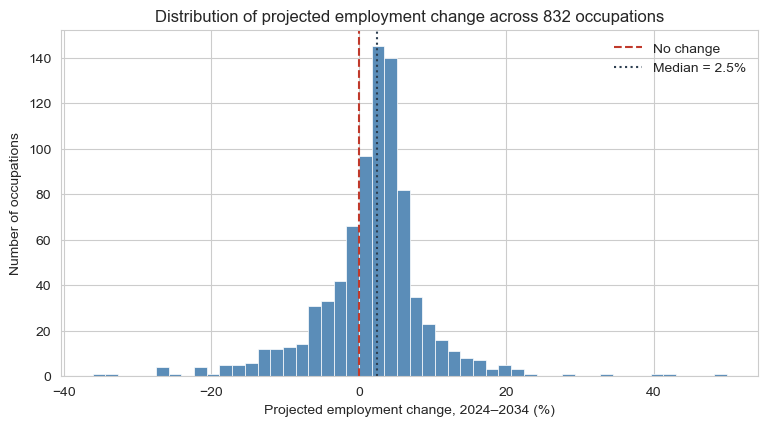

In [6]:
target = df['Employment Percent Change, 2024-2034']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(target, bins=50, color='#5B8DB8', edgecolor='white', linewidth=0.5)
ax.axvline(0, color='#C0392B', linestyle='--', linewidth=1.5, label='No change')
ax.axvline(target.median(), color='#2C3E50', linestyle=':', linewidth=1.5,
           label=f'Median = {target.median():.1f}%')
ax.set_xlabel('Projected employment change, 2024–2034 (%)')
ax.set_ylabel('Number of occupations')
ax.set_title('Distribution of projected employment change across 832 occupations')
ax.legend(frameon=False)
plt.show()

### 5.2 Decline rate by AI risk tier (Figure 4)

An important non-monotonic pattern: the "Very low" AI risk tier (manual occupations) also has an elevated decline rate, because those occupations are shrinking for *non-AI* reasons (mechanization, offshoring, demographic shifts in agriculture). Decline is most concentrated at the *high* end of AI exposure, but is not absent at the low end.

In [7]:
tier_order = ['Very low', 'Low', 'Moderate', 'High', 'Very high',
              'Very high (top-10 most exposed)']
agg = (df.groupby('AI Displacement Risk Tier')
         .agg(pct_declining=('Will Decline', 'mean'),
              n=('Will Decline', 'size'))
         .reindex(tier_order)
         .reset_index())
agg['pct_declining'] *= 100
agg

,AI Displacement Risk Tier,pct_declining,n
0,Very low,36.873156,339
1,Low,26.829268,41
2,Moderate,12.000000,200
3,High,19.444444,144
4,Very high,52.040816,98
5,Very high (top-10 most exposed),50.000000,10


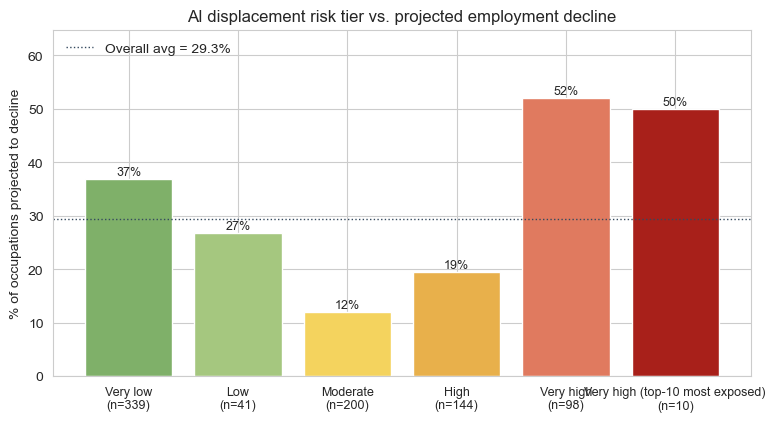

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#7FB069', '#A5C77F', '#F4D35E', '#E8B04B', '#E07A5F', '#A8201A']
bars = ax.bar(range(len(agg)), agg['pct_declining'], color=colors, edgecolor='white')
ax.set_xticks(range(len(agg)))
ax.set_xticklabels([f'{t}\n(n={n})' for t, n in zip(agg['AI Displacement Risk Tier'], agg['n'])],
                   fontsize=9)
ax.set_ylabel('% of occupations projected to decline')
ax.set_title('AI displacement risk tier vs. projected employment decline')
ax.axhline(df['Will Decline'].mean()*100, color='#34495E', linestyle=':',
           linewidth=1, label=f'Overall avg = {df["Will Decline"].mean()*100:.1f}%')
for bar, val in zip(bars, agg['pct_declining']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.7,
            f'{val:.0f}%', ha='center', fontsize=9)
ax.legend(frameon=False, loc='upper left')
ax.set_ylim(0, max(agg['pct_declining'])*1.15 + 5)
plt.show()

### 5.3 Decline rate by entry-level education (Figure 5)

In [9]:
edu_order = ['No formal educational credential',
             'High school diploma or equivalent',
             'Postsecondary nondegree award',
             'Some college, no degree',
             "Associate's degree",
             "Bachelor's degree",
             "Master's degree",
             'Doctoral or professional degree']
edu_agg = (df.groupby('Typical Entry-Level Education')
             .agg(pct_declining=('Will Decline', 'mean'),
                  median_change=('Employment Percent Change, 2024-2034', 'median'),
                  n=('Will Decline', 'size'))
             .reindex(edu_order)
             .reset_index())
edu_agg['pct_declining'] *= 100
edu_agg

,Typical Entry-Level Education,pct_declining,median_change,n
0,No formal educational credential,33.027523,2.00,109
1,High school diploma or equivalent,43.865031,1.05,326
2,Postsecondary nondegree award,19.607843,5.00,51
3,"Some college, no degree",71.428571,-1.50,7
4,Associate's degree,20.833333,2.75,48
5,Bachelor's degree,17.977528,3.80,178
6,Master's degree,12.500000,5.30,40
7,Doctoral or professional degree,4.109589,3.00,73


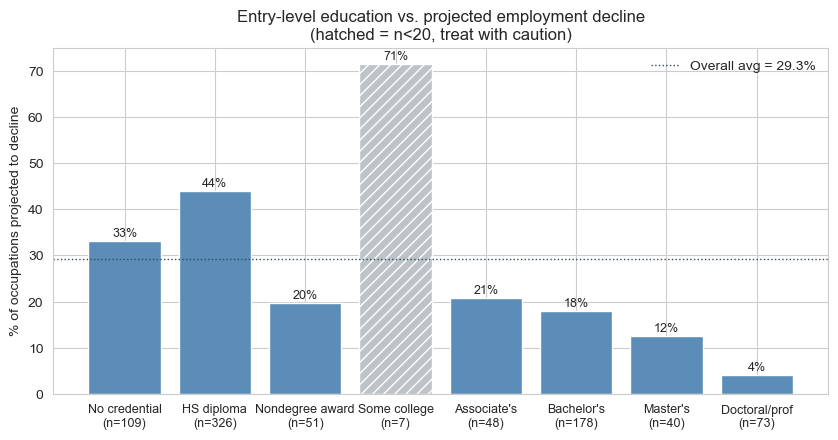

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
# Hatch small-n bars (n<20) to flag unreliability
bar_colors = ['#5B8DB8' if n >= 20 else '#BDC3C7' for n in edu_agg['n']]
bars = ax.bar(range(len(edu_agg)), edu_agg['pct_declining'],
               color=bar_colors, edgecolor='white')
for i, n in enumerate(edu_agg['n']):
    if n < 20:
        bars[i].set_hatch('///')
ax.set_xticks(range(len(edu_agg)))
short_labels = ['No credential', 'HS diploma', 'Nondegree award', 'Some college',
                "Associate's", "Bachelor's", "Master's", 'Doctoral/prof']
ax.set_xticklabels([f'{lbl}\n(n={n})' for lbl, n in zip(short_labels, edu_agg['n'])],
                   fontsize=9)
ax.set_ylabel('% of occupations projected to decline')
ax.set_title('Entry-level education vs. projected employment decline\n'
             '(hatched = n<20, treat with caution)')
ax.axhline(df['Will Decline'].mean()*100, color='#34495E', linestyle=':',
           linewidth=1, label=f'Overall avg = {df["Will Decline"].mean()*100:.1f}%')
for i, val in enumerate(edu_agg['pct_declining']):
    ax.text(i, val + 1, f'{val:.0f}%', ha='center', fontsize=9)
ax.legend(frameon=False)
plt.show()

### 5.4 Correlation matrix (Figure 6)

First-pass look at how the candidate features relate to the target and to each other.

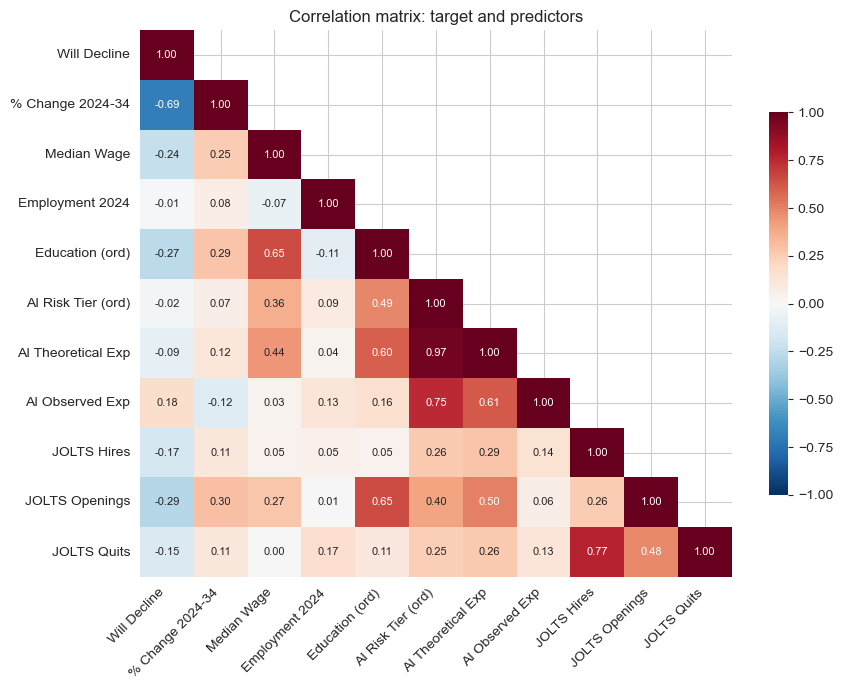

In [11]:
corr_cols = ['Will Decline',
             'Employment Percent Change, 2024-2034',
             'Median Annual Wage 2024',
             'Employment 2024',
             'Education Level',
             'Risk Tier (ordinal)',
             'AI Theor (imputed)',
             'AI Obs (imputed)',
             'JOLTS Hires Rate 2024 (%)',
             'JOLTS Job Openings Rate 2024 (%)',
             'JOLTS Quits Rate 2024 (%)']
display_names = {
    'Will Decline': 'Will Decline',
    'Employment Percent Change, 2024-2034': '% Change 2024-34',
    'Median Annual Wage 2024': 'Median Wage',
    'Employment 2024': 'Employment 2024',
    'Education Level': 'Education (ord)',
    'Risk Tier (ordinal)': 'AI Risk Tier (ord)',
    'AI Theor (imputed)': 'AI Theoretical Exp',
    'AI Obs (imputed)': 'AI Observed Exp',
    'JOLTS Hires Rate 2024 (%)': 'JOLTS Hires',
    'JOLTS Job Openings Rate 2024 (%)': 'JOLTS Openings',
    'JOLTS Quits Rate 2024 (%)': 'JOLTS Quits',
}
corr = df[corr_cols].corr()
corr.index = [display_names[c] for c in corr.index]
corr.columns = [display_names[c] for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=False, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation matrix: target and predictors')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.5 AI exposure vs projected change (Figure 7)

At high exposure, occupations bifurcate: a cluster pulled below zero (clerical and data-entry roles) and a cluster pulled well above zero (data scientists, security analysts, software developers).

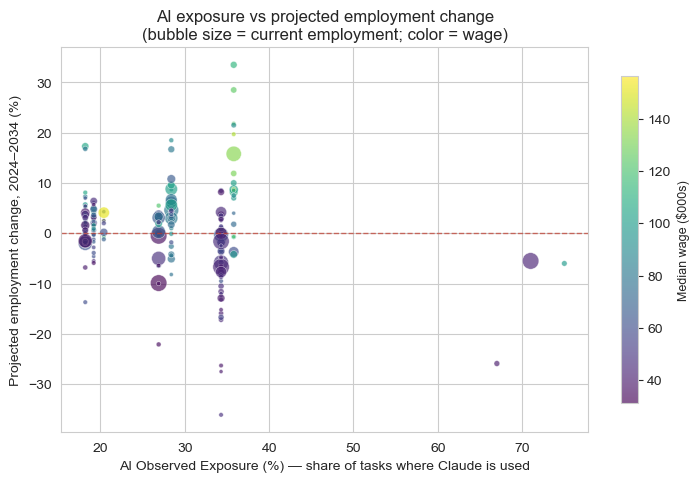

In [12]:
plot_df = df.dropna(subset=['AI Observed Exposure — Occupation (%)',
                              'Median Annual Wage 2024']).copy()
fig, ax = plt.subplots(figsize=(8.5, 5))
scatter = ax.scatter(plot_df['AI Observed Exposure — Occupation (%)'],
                      plot_df['Employment Percent Change, 2024-2034'],
                      c=plot_df['Median Annual Wage 2024']/1000, cmap='viridis',
                      alpha=0.65, s=plot_df['Employment 2024'].clip(upper=2000)/15 + 8,
                      edgecolor='white', linewidth=0.4)
ax.axhline(0, color='#C0392B', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('AI Observed Exposure (%) — share of tasks where Claude is used')
ax.set_ylabel('Projected employment change, 2024–2034 (%)')
ax.set_title('AI exposure vs projected employment change\n'
             '(bubble size = current employment; color = wage)')
cbar = plt.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_label('Median wage ($000s)', fontsize=9)
plt.show()

### 5.6 Skill correlations with decline and AI exposure

For each of the 35 O*NET skills, compute the Pearson correlation between the skill's importance rating and (i) the binary decline indicator, (ii) AI Observed Exposure. Plotting both correlations against each other reveals four quadrants: skills associated with decline + low AI exposure (manual obsolescence), skills associated with growth + high AI exposure (augmentation winners), etc.

We restrict to the 751 occupations that have skill data (90.3% of the BLS file).

In [13]:
# Restrict to occupations with skill data
df_sk = df.dropna(subset=SKILL_COLS).copy()
print(f'Subset with skills: {len(df_sk)} / {len(df)} '
      f'({len(df_sk)/len(df)*100:.1f}%)')
print(f'Decline rate in subset:  {df_sk["Will Decline"].mean()*100:.1f}%')
print(f'Decline rate in full:    {df["Will Decline"].mean()*100:.1f}%')
# (Subset rate should be very close to full rate — confirms skills coverage
#  is not selectively concentrated in growing or declining occupations.)

Subset with skills: 751 / 832 (90.3%)
Decline rate in subset:  30.2%
Decline rate in full:    29.3%


In [14]:
skill_corrs = pd.DataFrame({
    'Skill': SKILL_COLS,
    'r_decline': [df_sk[s].corr(df_sk['Will Decline']) for s in SKILL_COLS],
    'r_ai_obs':  [df_sk[s].corr(df_sk['AI Obs (imputed)']) for s in SKILL_COLS],
    'r_pct_change': [df_sk[s].corr(df_sk['Employment Percent Change, 2024-2034'])
                     for s in SKILL_COLS],
}).sort_values('r_decline', ascending=False)

print('Top 10 skills POSITIVELY correlated with decline:')
print(skill_corrs.head(10).to_string(index=False))
print('\nTop 10 skills NEGATIVELY correlated with decline (protective):')
print(skill_corrs.tail(10).to_string(index=False))

Top 10 skills POSITIVELY correlated with decline:
                   Skill  r_decline  r_ai_obs  r_pct_change
   Equipment Maintenance   0.115239 -0.397221     -0.108400
               Repairing   0.107668 -0.378662     -0.099620
   Operation and Control   0.092582 -0.498958     -0.133283
   Operations Monitoring   0.071535 -0.480206     -0.080924
     Equipment Selection   0.054249 -0.413957     -0.043484
         Troubleshooting   0.052988 -0.453381     -0.037008
Quality Control Analysis   0.033192 -0.433255     -0.018919
            Installation  -0.001669 -0.194858      0.019454
             Programming  -0.067763  0.324222      0.147953
             Mathematics  -0.093332  0.112577      0.161566

Top 10 skills NEGATIVELY correlated with decline (protective):
                            Skill  r_decline  r_ai_obs  r_pct_change
              Learning Strategies  -0.277550  0.087886      0.311426
                     Coordination  -0.280579 -0.004711      0.310814
                   

Horizontal bar chart of all 35 skills sorted by their correlation with decline:

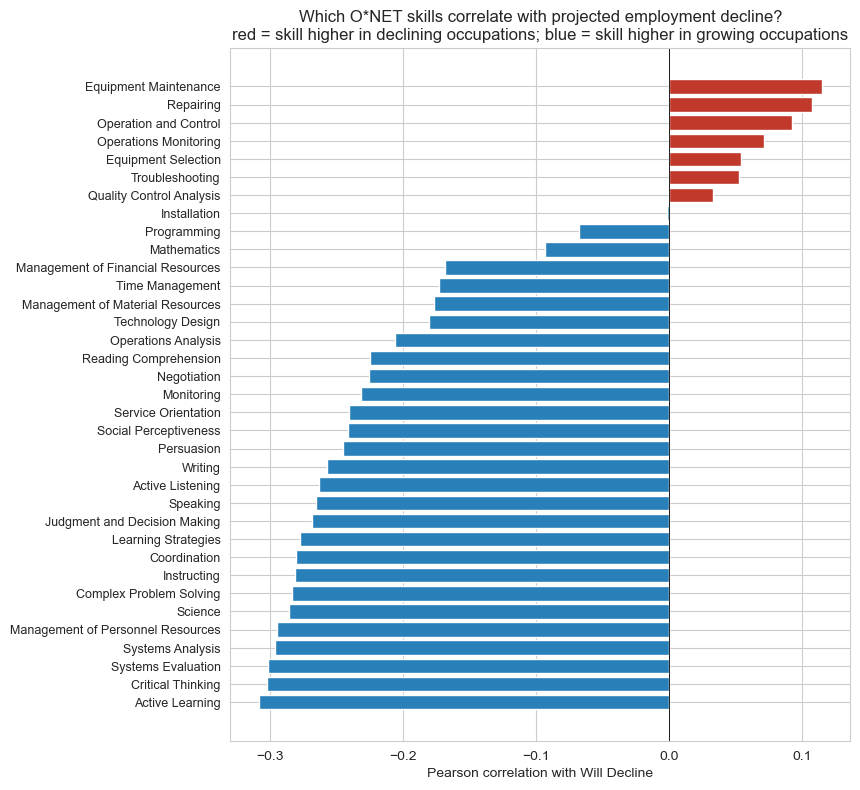

In [15]:
fig, ax = plt.subplots(figsize=(8, 9))
c_sorted = skill_corrs.sort_values('r_decline')
colors = ['#C0392B' if r > 0 else '#2980B9' for r in c_sorted['r_decline']]
ax.barh(range(len(c_sorted)), c_sorted['r_decline'], color=colors, edgecolor='white')
ax.set_yticks(range(len(c_sorted)))
ax.set_yticklabels(c_sorted['Skill'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Pearson correlation with Will Decline')
ax.set_title('Which O*NET skills correlate with projected employment decline?\n'
             'red = skill higher in declining occupations; blue = skill higher in growing occupations')
plt.show()

**The displacement quadrant analysis.** Plot each skill by its association with AI exposure (x-axis) and projected decline (y-axis). The top-right quadrant — high AI exposure AND associated with decline — is the "displacement quadrant". If AI were driving the projected employment declines, we would expect skills to cluster in the top right. They do not.

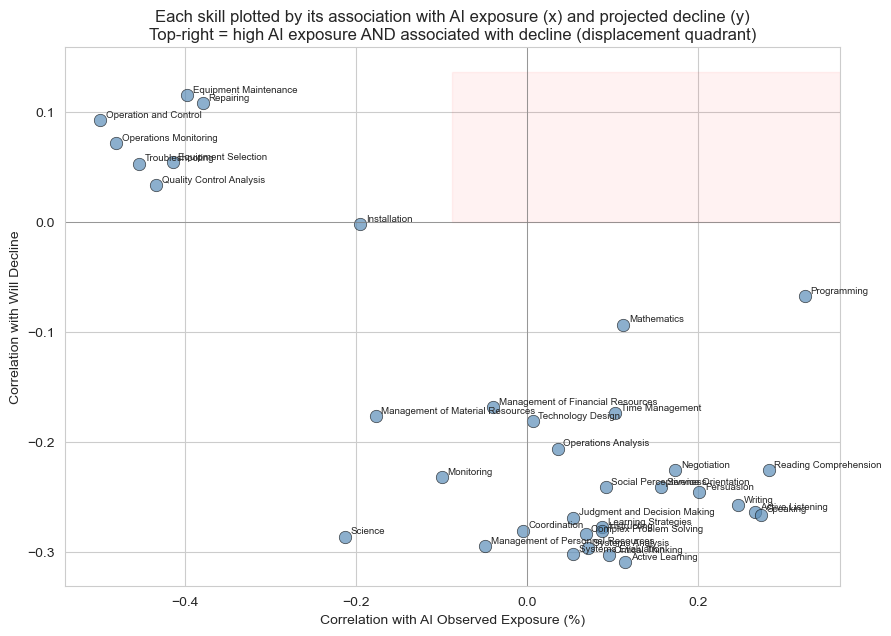

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(skill_corrs['r_ai_obs'], skill_corrs['r_decline'],
           s=80, alpha=0.7, edgecolor='black', linewidth=0.5, c='#5B8DB8')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
for _, row in skill_corrs.iterrows():
    ax.annotate(row['Skill'], (row['r_ai_obs'], row['r_decline']),
                xytext=(4, 2), textcoords='offset points', fontsize=7)
ax.set_xlabel('Correlation with AI Observed Exposure (%)')
ax.set_ylabel('Correlation with Will Decline')
ax.set_title('Each skill plotted by its association with AI exposure (x) and projected decline (y)\n'
             'Top-right = high AI exposure AND associated with decline (displacement quadrant)')
ax.axhspan(0, ax.get_ylim()[1], xmin=0.5, xmax=1, alpha=0.05, color='red')
plt.show()

**Reading the quadrant chart.** The displacement quadrant (upper right, lightly shaded) is empty. The skills most associated with projected decline (top-left cluster: Repairing, Equipment Maintenance, Operation and Control) are the *least* AI-exposed. The skills with the highest AI exposure (right side: Programming, Reading Comprehension, Speaking, Writing) are actually associated with employment *growth*, not decline. This is the same U-shape pattern we found in Section 5.2 with the AI risk tier, now visible at the skill level: the contraction is happening at the manual/operational end of the labor market, not at the high-AI-exposure cognitive end.

### 5.7 PCA on the 35 skills — extracting combined-skill factors

The 35 skills are highly intercorrelated, so we use PCA to find a small number of orthogonal combined-skill factors. The first four components are interpretable:
- **PC1** — a general cognitive/communication index (reading, writing, critical thinking, complex problem solving). 49% of variance.
- **PC2** — a physical/operational index (troubleshooting, repairing, equipment skills). 18% of variance.
- **PC3** — STEM (programming, math, science) vs people/service skills. 7% of variance.
- **PC4** — financial/material management vs teaching/learning. 5% of variance.

The first two components alone explain 67% of the variation across the 35 raw skills, and have very clean substantive interpretations.

In [17]:
from sklearn.decomposition import PCA

X_skills = StandardScaler().fit_transform(df_sk[SKILL_COLS])
pca = PCA(n_components=10)
pca_scores = pca.fit_transform(X_skills)
explained = pca.explained_variance_ratio_

print('Variance explained by each PC:')
for i, v in enumerate(explained):
    print(f'  PC{i+1}: {v:.1%}  (cumulative: {explained[:i+1].sum():.1%})')

Variance explained by each PC:
  PC1: 49.0%  (cumulative: 49.0%)
  PC2: 18.3%  (cumulative: 67.3%)
  PC3: 6.6%  (cumulative: 73.9%)
  PC4: 4.5%  (cumulative: 78.4%)
  PC5: 3.0%  (cumulative: 81.4%)
  PC6: 2.0%  (cumulative: 83.3%)
  PC7: 1.9%  (cumulative: 85.2%)
  PC8: 1.6%  (cumulative: 86.8%)
  PC9: 1.5%  (cumulative: 88.2%)
  PC10: 1.1%  (cumulative: 89.4%)


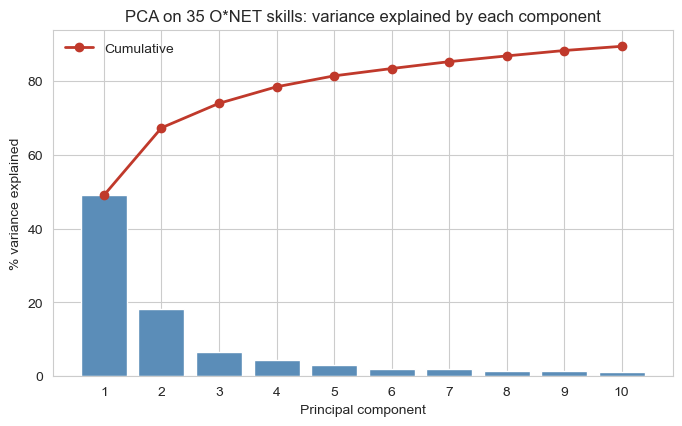

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(1, 11), explained * 100, color='#5B8DB8', edgecolor='white')
ax.plot(range(1, 11), np.cumsum(explained) * 100, color='#C0392B',
        marker='o', linewidth=2, label='Cumulative')
ax.set_xlabel('Principal component')
ax.set_ylabel('% variance explained')
ax.set_title('PCA on 35 O*NET skills: variance explained by each component')
ax.legend(frameon=False)
ax.set_xticks(range(1, 11))
plt.show()

Loadings for the first two components — i.e., which skills cluster together to form the combined-skill factor:

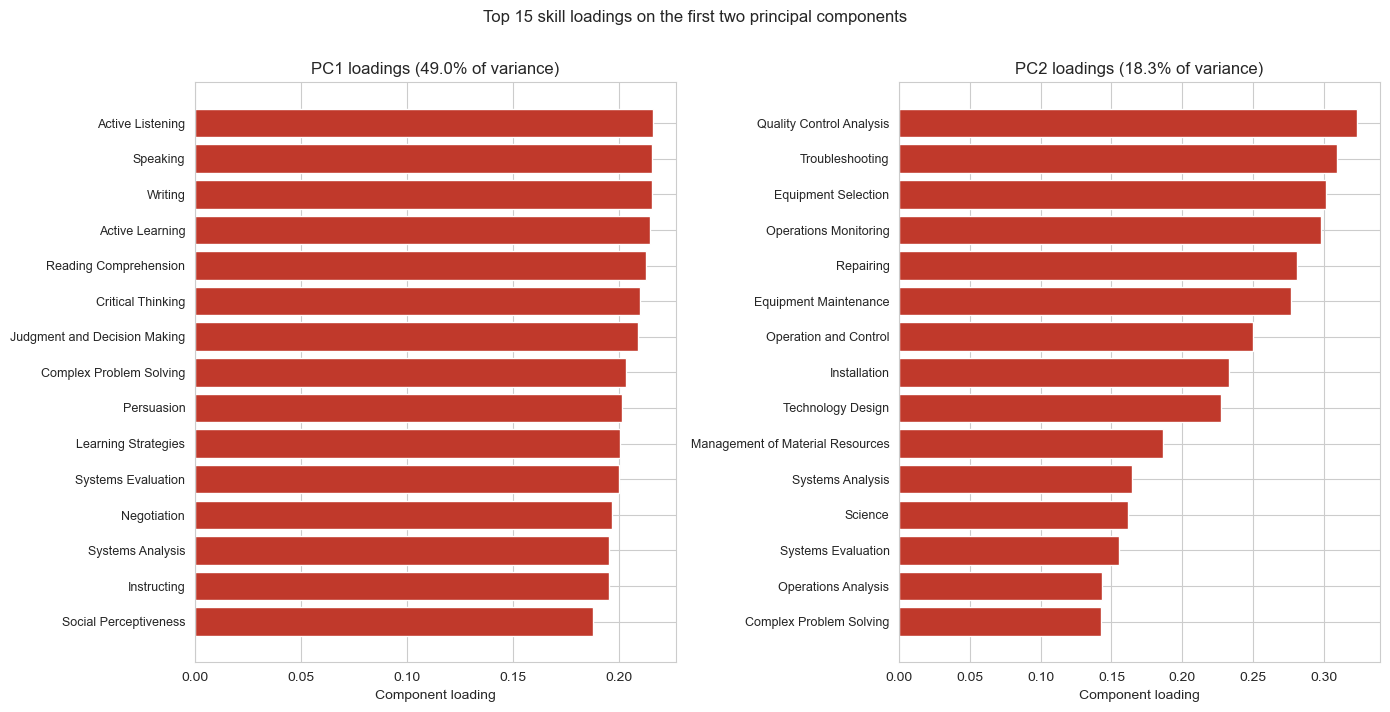

In [19]:
loadings = pd.DataFrame(pca.components_[:4].T,
                        columns=['PC1','PC2','PC3','PC4'],
                        index=SKILL_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    top = loadings[pc].abs().sort_values(ascending=False).head(15)
    sub = loadings.loc[top.index, pc].sort_values()
    colors = ['#C0392B' if v > 0 else '#2980B9' for v in sub.values]
    ax.barh(range(len(sub)), sub.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub.index, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_xlabel('Component loading')
    var_pct = pca.explained_variance_ratio_[int(pc[-1])-1] * 100
    ax.set_title(f'{pc} loadings ({var_pct:.1f}% of variance)')
plt.suptitle('Top 15 skill loadings on the first two principal components',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# Show the top loadings on PC3 and PC4 as well (smaller magnitudes but still interpretable)
for pc in ['PC3', 'PC4']:
    top = loadings[pc].abs().sort_values(ascending=False).head(8)
    print(f'\n{pc} ({pca.explained_variance_ratio_[int(pc[-1])-1]:.1%} of variance):')
    for skill, _ in top.items():
        val = loadings.loc[skill, pc]
        direction = '+' if val > 0 else '−'
        print(f'  {direction} {skill:35s}  ({val:+.2f})')


PC3 (6.6% of variance):
  + Programming                          (+0.35)
  − Coordination                         (-0.31)
  + Science                              (+0.27)
  + Mathematics                          (+0.25)
  − Management of Material Resources     (-0.25)
  − Management of Personnel Resources    (-0.24)
  − Service Orientation                  (-0.23)
  − Social Perceptiveness                (-0.23)

PC4 (4.5% of variance):
  + Management of Financial Resources    (+0.50)
  + Management of Material Resources     (+0.43)
  + Mathematics                          (+0.23)
  − Instructing                          (-0.22)
  − Learning Strategies                  (-0.22)
  − Monitoring                           (-0.21)
  + Operations Analysis                  (+0.19)
  + Programming                          (+0.17)


In [21]:
# Attach PC scores to the subset dataframe for use in modeling below
for i in range(4):
    df_sk[f'Skill PC{i+1}'] = pca_scores[:, i]

# Quick correlations of each PC with the target
print('PC correlations with Will Decline:')
for i in range(4):
    r = df_sk[f'Skill PC{i+1}'].corr(df_sk['Will Decline'])
    print(f'  PC{i+1}: r = {r:+.3f}')

PC correlations with Will Decline:
  PC1: r = -0.302
  PC2: r = -0.104
  PC3: r = +0.050
  PC4: r = +0.075


### 6. Multicollinearity check

Before fitting models, check Variance Inflation Factors (VIF). Conventionally, VIF > 5 indicates problematic collinearity that destabilizes coefficient estimates.

In [22]:
candidate_features = [
    'Education Level', 'Risk Tier (ordinal)',
    'AI Theor (imputed)', 'AI Obs (imputed)',
    'log Wage', 'log Emp 2024',
    'JOLTS Hires Rate 2024 (%)', 'JOLTS Quits Rate 2024 (%)',
    'JOLTS Job Openings Rate 2024 (%)',
]
X_scaled = StandardScaler().fit_transform(df[candidate_features])
vifs = pd.DataFrame({
    'Feature': candidate_features,
    'VIF': [variance_inflation_factor(X_scaled, i) for i in range(len(candidate_features))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vifs

,Feature,VIF
0,Risk Tier (ordinal),45.466105
1,AI Theor (imputed),38.471572
2,AI Obs (imputed),4.288368
3,Education Level,3.852412
4,JOLTS Quits Rate 2024 (%),3.678497
5,JOLTS Job Openings Rate 2024 (%),3.133935
6,JOLTS Hires Rate 2024 (%),2.992927
7,log Wage,2.245521
8,log Emp 2024,1.155085


Risk Tier (ordinal) and AI Theoretical Exposure have VIFs above 30 — they are nearly redundant (pairwise correlation ~0.97), since the Risk Tier was originally derived from the AI exposure values. We drop `Risk Tier` from the model and keep the two continuous exposure measures.

In [23]:
model_features = [
    'Education Level',
    'AI Theor (imputed)', 'AI Obs (imputed)',
    'log Wage', 'log Emp 2024',
    'JOLTS Hires Rate 2024 (%)', 'JOLTS Quits Rate 2024 (%)',
    'JOLTS Job Openings Rate 2024 (%)',
]
X = StandardScaler().fit_transform(df[model_features])
vifs_after = pd.DataFrame({
    'Feature': model_features,
    'VIF': [variance_inflation_factor(X, i) for i in range(len(model_features))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
print('VIFs after dropping Risk Tier:')
vifs_after

VIFs after dropping Risk Tier:


,Feature,VIF
0,Education Level,3.642752
1,JOLTS Quits Rate 2024 (%),3.610767
2,AI Theor (imputed),3.564339
3,JOLTS Job Openings Rate 2024 (%),3.105200
4,JOLTS Hires Rate 2024 (%),2.903126
5,log Wage,2.227593
6,AI Obs (imputed),2.110919
7,log Emp 2024,1.129514


### 7. Logistic regression — P(Decline)

In [24]:
y_bin = df['Will Decline']

logit = LogisticRegression(max_iter=2000, random_state=42)
logit.fit(X, y_bin)
df['P(Decline)'] = logit.predict_proba(X)[:, 1]

auc_in = roc_auc_score(y_bin, df['P(Decline)'])
cv_auc = cross_val_score(logit, X, y_bin, cv=5, scoring='roc_auc')
print(f'In-sample AUC: {auc_in:.3f}')
print(f'5-fold CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')

coef_df = pd.DataFrame({
    'Feature': model_features,
    'Coefficient (std)': logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0]),
}).sort_values('Coefficient (std)', key=abs, ascending=False).reset_index(drop=True)
coef_df

In-sample AUC: 0.790
5-fold CV AUC: 0.773 ± 0.031


,Feature,Coefficient (std),Odds Ratio
0,AI Obs (imputed),0.613628,1.847120
1,JOLTS Hires Rate 2024 (%),-0.602594,0.547390
2,log Emp 2024,-0.547436,0.578431
3,log Wage,-0.440896,0.643460
4,Education Level,-0.438977,0.644695
5,JOLTS Job Openings Rate 2024 (%),-0.431213,0.649720
6,JOLTS Quits Rate 2024 (%),0.304959,1.356570
7,AI Theor (imputed),0.178757,1.195730


### 7.1 ROC curve (Figure 2)

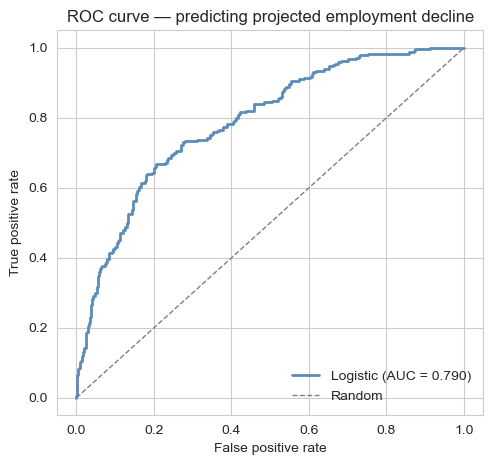

In [25]:
fpr, tpr, _ = roc_curve(y_bin, df['P(Decline)'])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color='#5B8DB8', linewidth=2, label=f'Logistic (AUC = {auc_in:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve — predicting projected employment decline')
ax.legend(frameon=False, loc='lower right')
plt.show()

### 7.2 Logistic coefficients

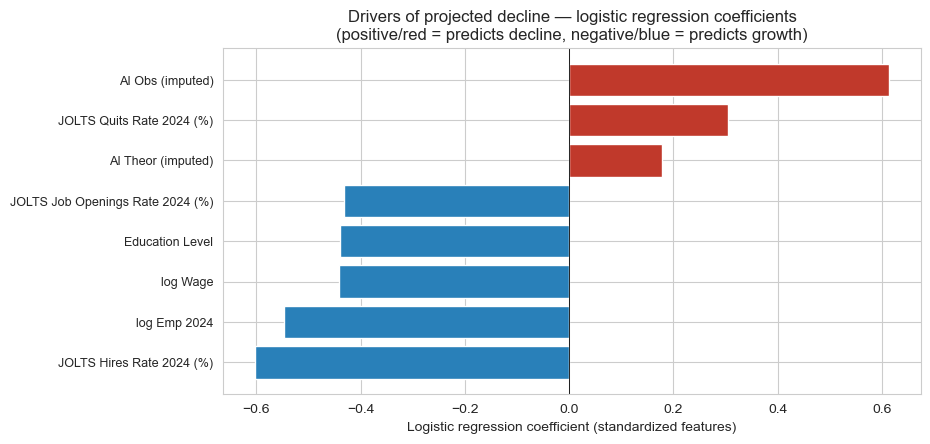

In [26]:
fig, ax = plt.subplots(figsize=(9, 4.5))
coef_sorted = coef_df.sort_values('Coefficient (std)')
colors_lr = ['#C0392B' if c > 0 else '#2980B9' for c in coef_sorted['Coefficient (std)']]
ax.barh(range(len(coef_sorted)), coef_sorted['Coefficient (std)'],
         color=colors_lr, edgecolor='white')
ax.set_yticks(range(len(coef_sorted)))
ax.set_yticklabels(coef_sorted['Feature'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Logistic regression coefficient (standardized features)')
ax.set_title('Drivers of projected decline — logistic regression coefficients\n'
             '(positive/red = predicts decline, negative/blue = predicts growth)')
plt.show()

### 8. Linear regression — magnitude of % change

The logistic model answers *whether* an occupation will decline; the linear model answers *by how much* an occupation's employment is projected to change.

In [27]:
y_cont = df['Employment Percent Change, 2024-2034']

linreg = LinearRegression()
linreg.fit(X, y_cont)
df['Predicted % Change'] = linreg.predict(X)

r2_in = linreg.score(X, y_cont)
cv_r2 = cross_val_score(linreg, X, y_cont, cv=5, scoring='r2')
print(f'In-sample R²: {r2_in:.3f}')
print(f'5-fold CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')

lin_coef = pd.DataFrame({
    'Feature': model_features,
    'Coefficient (std)': linreg.coef_,
}).sort_values('Coefficient (std)', key=abs, ascending=False).reset_index(drop=True)
lin_coef

In-sample R²: 0.221
5-fold CV R²: 0.177 ± 0.100


,Feature,Coefficient (std)
0,log Emp 2024,2.062927
1,JOLTS Job Openings Rate 2024 (%),1.881917
2,JOLTS Hires Rate 2024 (%),1.501282
3,log Wage,1.409732
4,JOLTS Quits Rate 2024 (%),-1.245840
5,AI Obs (imputed),-1.199656
6,AI Theor (imputed),-0.950448
7,Education Level,0.933762


### 8.1 Feature importance — side-by-side (Figure 8)

Both models converge on the same direction of effect for every feature, which is a reassurance that the patterns are not artifacts of model choice.

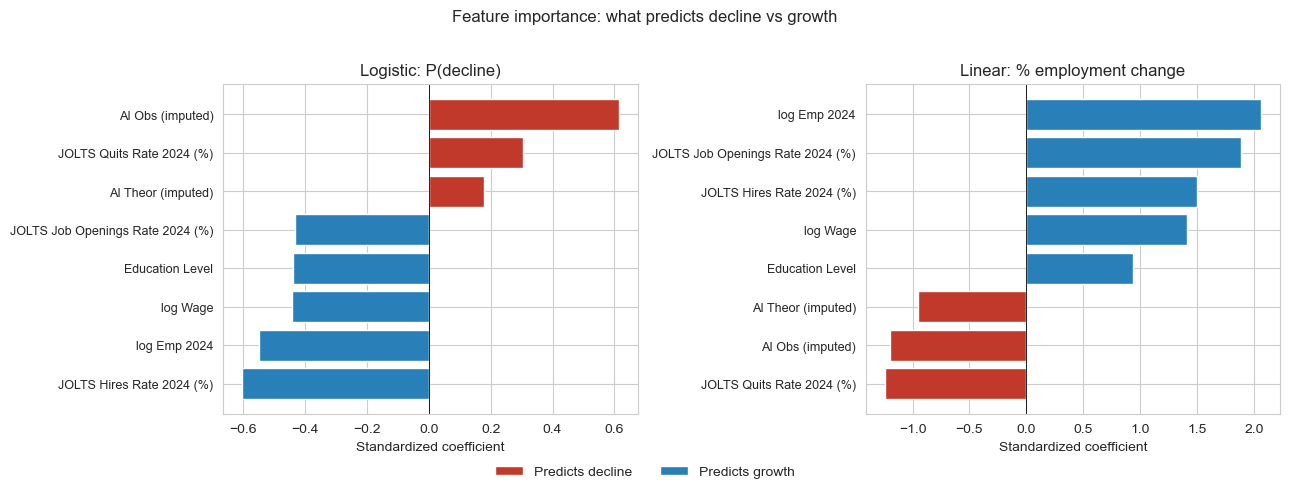

In [28]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: logistic — positive coef = predicts decline = red
log_sorted = coef_df.sort_values('Coefficient (std)')
log_colors = ['#C0392B' if c > 0 else '#2980B9' for c in log_sorted['Coefficient (std)']]
axes[0].barh(range(len(log_sorted)), log_sorted['Coefficient (std)'],
              color=log_colors, edgecolor='white')
axes[0].set_yticks(range(len(log_sorted)))
axes[0].set_yticklabels(log_sorted['Feature'], fontsize=9)
axes[0].axvline(0, color='black', linewidth=0.6)
axes[0].set_xlabel('Standardized coefficient')
axes[0].set_title('Logistic: P(decline)')

# Right: linear — NEGATIVE coef = predicts decline = red
lin_sorted = lin_coef.sort_values('Coefficient (std)')
lin_colors = ['#2980B9' if c > 0 else '#C0392B' for c in lin_sorted['Coefficient (std)']]
axes[1].barh(range(len(lin_sorted)), lin_sorted['Coefficient (std)'],
              color=lin_colors, edgecolor='white')
axes[1].set_yticks(range(len(lin_sorted)))
axes[1].set_yticklabels(lin_sorted['Feature'], fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.6)
axes[1].set_xlabel('Standardized coefficient')
axes[1].set_title('Linear: % employment change')

fig.legend(handles=[Patch(facecolor='#C0392B', label='Predicts decline'),
                     Patch(facecolor='#2980B9', label='Predicts growth')],
            loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Feature importance: what predicts decline vs growth', y=1.02)
plt.tight_layout()
plt.show()

**Note on model fit.** The CV AUC of ~0.77 indicates moderate but not strong discriminative power, and the CV R² of ~0.18 indicates that the available features explain about a fifth of the variance in projected employment change. The model is useful for relative ranking but should not be treated as a precise forecast — projected employment depends on many factors not captured here (industry-specific demand shifts, immigration policy, healthcare and demographic trends, etc.).

### 9. Threshold analysis for binary classification

How does the choice of probability cut-off affect precision and recall? At what threshold should we call an occupation "likely to decline"?

In [29]:
rows = []
for thr in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    pred = (df['P(Decline)'] >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, pred).ravel()
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2*prec*rec / max(prec + rec, 1e-9)
    rows.append({'Threshold': thr, 'Predicted decline': pred.sum(),
                 'TP': tp, 'FP': fp, 'FN': fn,
                 'Precision': round(prec, 3), 'Recall': round(rec, 3),
                 'F1': round(f1, 3)})
pd.DataFrame(rows)

,Threshold,Predicted decline,TP,FP,FN,Precision,Recall,F1
0,0.20,459,200,259,44,0.436,0.820,0.569
1,0.25,399,185,214,59,0.464,0.758,0.575
2,0.30,337,176,161,68,0.522,0.721,0.606
3,0.35,278,160,118,84,0.576,0.656,0.613
4,0.40,234,142,92,102,0.607,0.582,0.594
5,0.45,199,122,77,122,0.613,0.500,0.551
6,0.50,162,104,58,140,0.642,0.426,0.512


### 9.1 Threshold sweep curves (Figure 3)

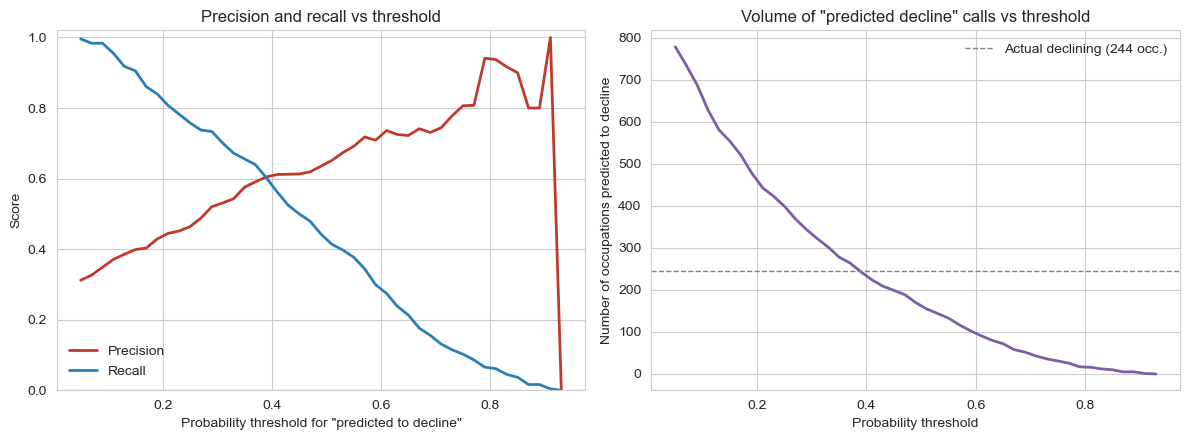

In [30]:
all_thresholds = np.arange(0.05, 0.95, 0.02)
sweep = []
for thr in all_thresholds:
    pred = (df['P(Decline)'] >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, pred).ravel()
    sweep.append({
        'thr': thr,
        'precision': tp / max(tp + fp, 1),
        'recall':    tp / max(tp + fn, 1),
        'pred_count': pred.sum(),
    })
sweep_df = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(sweep_df['thr'], sweep_df['precision'], color='#C0392B',
              linewidth=2, label='Precision')
axes[0].plot(sweep_df['thr'], sweep_df['recall'], color='#2980B9',
              linewidth=2, label='Recall')
axes[0].set_xlabel('Probability threshold for "predicted to decline"')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision and recall vs threshold')
axes[0].legend(frameon=False)
axes[0].set_ylim(0, 1.02)

axes[1].plot(sweep_df['thr'], sweep_df['pred_count'], color='#7B5EA7', linewidth=2)
axes[1].axhline(y_bin.sum(), color='gray', linestyle='--', linewidth=1,
                 label=f'Actual declining ({y_bin.sum()} occ.)')
axes[1].set_xlabel('Probability threshold')
axes[1].set_ylabel('Number of occupations predicted to decline')
axes[1].set_title('Volume of "predicted decline" calls vs threshold')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

**Reading this.** At the natural threshold of 0.5, the model is precise (64%) but only catches 43% of the actually-declining occupations. Lowering the threshold to 0.40 raises recall to 58% at the cost of precision falling to 61% — a roughly balanced operating point. The F1 score peaks around 0.30 (recall 73%, precision 52%). Threshold choice depends on use case: if the cost of missing a declining occupation is high (e.g., workforce planning), pick a lower threshold; if false alarms are costly, pick higher.

## 10. Three-way model comparison: does adding skills improve prediction?

We fit the logistic and linear models three times:
1. **Base** — the 8 features from Section 6 (education, AI exposure, log wage, log employment, JOLTS rates).
2. **Base + 35 skills** — all individual O*NET skills added.
3. **Base + 4 PCs** — the first four skill principal components added.

All three models are evaluated with 5-fold cross-validation on the 751 occupations with skill data.

In [31]:
def fit_and_cv(features, y_bin, y_cont, data):
    X = StandardScaler().fit_transform(data[features])
    log = LogisticRegression(max_iter=2000, random_state=42).fit(X, y_bin)
    lin = LinearRegression().fit(X, y_cont)
    cv_auc = cross_val_score(log, X, y_bin, cv=5, scoring='roc_auc')
    cv_r2  = cross_val_score(lin, X, y_cont, cv=5, scoring='r2')
    return {
        'features': features,
        'cv_auc':     cv_auc.mean(), 'cv_auc_std': cv_auc.std(),
        'cv_r2':      cv_r2.mean(),  'cv_r2_std':  cv_r2.std(),
        'log': log, 'lin': lin, 'X': X,
    }

base_features_skills = model_features  # Same 8 features used earlier
y_sk      = df_sk['Will Decline']
y_cont_sk = df_sk['Employment Percent Change, 2024-2034']

PC_FEATURES = [f'Skill PC{i+1}' for i in range(4)]

results = {
    'base':          fit_and_cv(base_features_skills,                       y_sk, y_cont_sk, df_sk),
    'base + skills': fit_and_cv(base_features_skills + SKILL_COLS,          y_sk, y_cont_sk, df_sk),
    'base + PCs':    fit_and_cv(base_features_skills + PC_FEATURES,         y_sk, y_cont_sk, df_sk),
}

print(f'{"Model":16s}  {"CV AUC":>14s}  {"CV R²":>14s}  Features')
for name, r in results.items():
    print(f'  {name:14s}  '
          f'{r["cv_auc"]:.3f}±{r["cv_auc_std"]:.3f}   '
          f'{r["cv_r2"]:+.3f}±{r["cv_r2_std"]:.3f}    {len(r["features"])}')

Model                     CV AUC           CV R²  Features
  base            0.785±0.025   +0.191±0.074    8
  base + skills   0.783±0.043   +0.174±0.108    43
  base + PCs      0.783±0.031   +0.188±0.107    12


### 10.1 Visual comparison

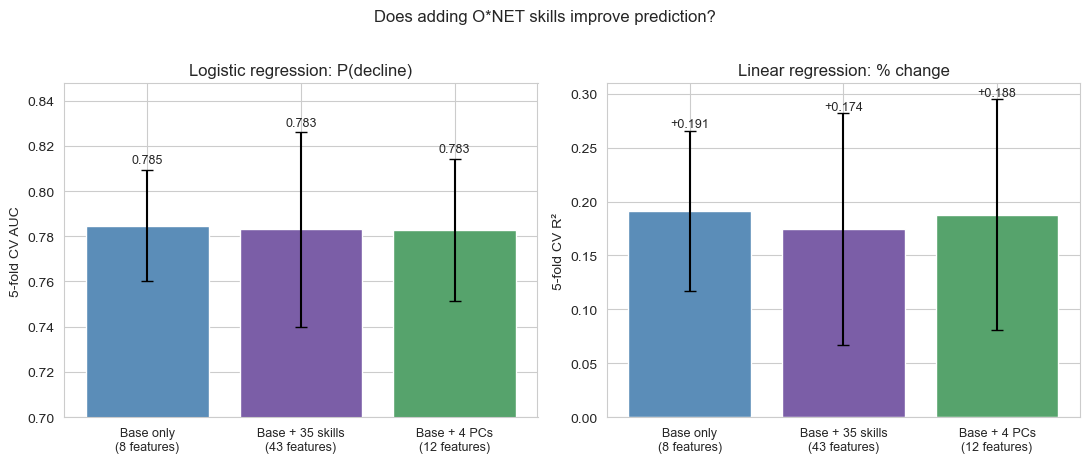

In [32]:
names = list(results.keys())
names_pretty = ['Base only\n(8 features)', 'Base + 35 skills\n(43 features)',
                 'Base + 4 PCs\n(12 features)']
aucs   = [results[n]['cv_auc']     for n in names]
errs_a = [results[n]['cv_auc_std'] for n in names]
r2s    = [results[n]['cv_r2']      for n in names]
errs_r = [results[n]['cv_r2_std']  for n in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(range(3), aucs, yerr=errs_a, color=['#5B8DB8', '#7B5EA7', '#56A36C'],
            edgecolor='white', capsize=4)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(names_pretty, fontsize=9)
axes[0].set_ylabel('5-fold CV AUC')
axes[0].set_title('Logistic regression: P(decline)')
axes[0].set_ylim(0.7, max(aucs) + max(errs_a) + 0.02)
for i, (a, e) in enumerate(zip(aucs, errs_a)):
    axes[0].text(i, a + e + 0.003, f'{a:.3f}', ha='center', fontsize=9)

axes[1].bar(range(3), r2s, yerr=errs_r, color=['#5B8DB8', '#7B5EA7', '#56A36C'],
            edgecolor='white', capsize=4)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(names_pretty, fontsize=9)
axes[1].set_ylabel('5-fold CV R²')
axes[1].set_title('Linear regression: % change')
for i, (a, e) in enumerate(zip(r2s, errs_r)):
    axes[1].text(i, a + e + 0.003, f'{a:+.3f}', ha='center', fontsize=9)

plt.suptitle('Does adding O*NET skills improve prediction?', y=1.02)
plt.tight_layout()
plt.show()

**The overall finding.** All three models perform essentially identically. CV AUC is 0.78 ± 0.03 in every case; the error bars overlap entirely. Adding 35 individual skills or 4 PCs gives no measurable lift over the base 8 features.

**Why?** The base features already include AI exposure, education, wage, and employment size — and these are themselves strong proxies for the skill mix of an occupation. By the time you've controlled for education level and AI exposure, the marginal predictive content of skill ratings is small. This is consistent with the descriptive finding in 5.6: the most decline-associated skills are "low-AI-exposure" manual skills, which are already captured indirectly by the AI exposure feature being low for those occupations.

**What the skills are useful for.** Interpretation and storytelling. Section 5.6 lets you say which specific skills are concentrated in declining occupations and which are protective — much more actionable for individuals than "low-AI-exposure occupations are at risk". For a policy or career-guidance audience, the skill-level findings are the most concrete output. For prediction, the base features are sufficient.

### 10.2 Coefficient inspection — what do the PCs tell us in the regression?

                         Feature  Coefficient (std)  Odds Ratio
       JOLTS Hires Rate 2024 (%)          -0.741763    0.476273
                AI Obs (imputed)           0.580418    1.786785
                    log Emp 2024          -0.577760    0.561154
                       Skill PC1          -0.547049    0.578655
       JOLTS Quits Rate 2024 (%)           0.533144    1.704282
JOLTS Job Openings Rate 2024 (%)          -0.459246    0.631760
              AI Theor (imputed)           0.429672    1.536754
                        log Wage          -0.314268    0.730323
                 Education Level          -0.308042    0.734884
                       Skill PC2           0.048956    1.050174
                       Skill PC3          -0.013358    0.986731
                       Skill PC4          -0.009612    0.990434


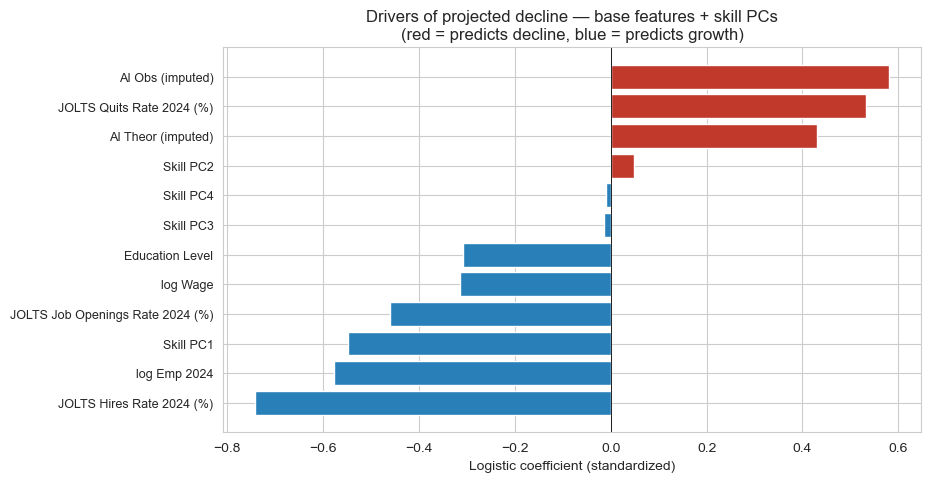

In [33]:
pc_features_all = base_features_skills + PC_FEATURES
pc_results = results['base + PCs']
coef_df = pd.DataFrame({
    'Feature': pc_features_all,
    'Coefficient (std)': pc_results['log'].coef_[0],
    'Odds Ratio': np.exp(pc_results['log'].coef_[0]),
}).sort_values('Coefficient (std)', key=abs, ascending=False)
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
c_sorted = coef_df.sort_values('Coefficient (std)')
colors = ['#C0392B' if c > 0 else '#2980B9' for c in c_sorted['Coefficient (std)']]
ax.barh(range(len(c_sorted)), c_sorted['Coefficient (std)'], color=colors, edgecolor='white')
ax.set_yticks(range(len(c_sorted)))
ax.set_yticklabels(c_sorted['Feature'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Logistic coefficient (standardized)')
ax.set_title('Drivers of projected decline — base features + skill PCs\n'
             '(red = predicts decline, blue = predicts growth)')
plt.show()

**Note.** Of the four skill PCs, only PC1 (general cognitive/communication skills) has a substantial standardized coefficient; and it's strongly negative, meaning higher cognitive-skill loading predicts growth, rather than decline. PC2 (physical/operational), PC3 (STEM vs service), and PC4 (financial management) all have near-zero coefficients once the base features are included. This is what "no predictive lift" looks like up close: the one PC that does carry signal is essentially redundant with education level and wage (themselves correlates of cognitive complexity).

## 11. Highest- and lowest-risk occupations

In [34]:
display_cols = ['Occupation Title (clean)', 'P(Decline)',
                'Employment Percent Change, 2024-2034',
                'AI Observed Exposure — Occupation (%)',
                'Median Annual Wage 2024']
print('=== Top 15 highest P(Decline) ===')
print(df.nlargest(15, 'P(Decline)')[display_cols].to_string(index=False))

=== Top 15 highest P(Decline) ===
                                                Occupation Title (clean)  P(Decline)  Employment Percent Change, 2024-2034  AI Observed Exposure — Occupation (%)  Median Annual Wage 2024
                                                       Data entry keyers    0.927188                                 -25.9                                   67.0                  39850.0
                           Communications equipment operators, all other    0.904948                                   2.5                                   34.3                  49910.0
                              Gambling change persons and booth cashiers    0.899785                                  -6.4                                   26.9                  34810.0
                                                     Telephone operators    0.898200                                 -27.5                                   34.3                  39130.0
Door-to-door sales workers, new

In [35]:
print('=== Top 15 lowest P(Decline) ===')
print(df.nsmallest(15, 'P(Decline)')[display_cols].to_string(index=False))

=== Top 15 lowest P(Decline) ===
                      Occupation Title (clean)  P(Decline)  Employment Percent Change, 2024-2034  AI Observed Exposure — Occupation (%)  Median Annual Wage 2024
                    Family medicine physicians    0.010990                                   2.7                                    NaN                 238380.0
          General internal medicine physicians    0.012908                                   3.3                                    NaN                 236350.0
                                   Pharmacists    0.014278                                   4.6                                    NaN                 137480.0
                             Dentists, general    0.015131                                   4.1                                    NaN                 172790.0
                             Registered nurses    0.016180                                   4.9                                    NaN                  93600.0
 

## 12. Export predictions

In [36]:
output_cols = ['Occupation Title (clean)', 'Occupation Code',
               'Employment 2024', 'Employment 2034',
               'Employment Percent Change, 2024-2034', 'Will Decline',
               'P(Decline)', 'Predicted % Change',
               'Median Annual Wage 2024', 'Typical Entry-Level Education',
               'AI Theoretical Exposure (%)', 'AI Observed Exposure — Occupation (%)',
               'AI Displacement Risk Tier',
               'JOLTS Hires Rate 2024 (%)',
               'JOLTS Job Openings Rate 2024 (%)',
               'JOLTS Quits Rate 2024 (%)']
df[output_cols].to_csv('Predictions_by_Occupation.csv', index=False)
print(f'Wrote {len(df)} rows × {len(output_cols)} columns')

Wrote 832 rows × 16 columns


## Summary of findings

### Modeling
1. **~29% of occupations are projected to decline** in employment between 2024 and 2034.
2. **The base model has moderate discriminative power** (5-fold CV AUC ≈ 0.78) but limited explanatory power for the magnitude of change (CV R² ≈ 0.19). Use it for ranking, not point forecasts.
3. **Adding O*NET skills (raw or via PCA) does not improve out-of-sample prediction.** All three models — base, base+35 skills, base+4 PCs — produce CV AUC of 0.78 ± 0.03 (Section 10). The skills add interpretive depth but not predictive lift.

### Drivers of decline
4. **Strongest predictors of decline** (in the base model): high AI observed exposure (Claude actually being used for these tasks), low JOLTS hires rate (industry isn't hiring fast), small occupation size, and lower entry-level education.
5. **Strongest predictors of growth**: higher entry-level education, higher wages, higher industry hires and openings rates, and (Section 10.2) higher loading on the general cognitive-skills component (Skill PC1).
6. **The relationship between AI risk tier and decline is non-monotonic**: Both the "Very high" and "Very low" tiers have elevated decline rates. The high end reflects AI displacement of cognitive office work; the low end reflects long-running automation and structural decline in manual occupations.

### Skill-level findings (new in v3)
7. **Skills most associated with projected decline**: Equipment Maintenance, Repairing, Operation and Control, Operations Monitoring, Equipment Selection (Section 5.6). These are manual/operational skills — and notably they are also the *least* AI-exposed skills.
8. **Skills most protective against decline**: Active Learning, Critical Thinking, Systems Evaluation, Systems Analysis, Management of Personnel Resources. These are higher-order cognitive and managerial skills, consistent with what protects against displacement in the post-1980 labor economics literature.
9. **Skills most exposed to AI**: Programming, Reading Comprehension, Speaking, Active Listening, Writing — the LLM-tractable cognitive skills. These skills are *negatively* correlated with decline.
10. **The "displacement quadrant" is empty** (Section 5.6 chart). No skill is both highly AI-exposed AND associated with projected decline. The current AI exposure measures and the projected decline patterns are largely orthogonal at the skill level, which complicates simple "AI is causing the projected declines" narratives.
11. **PCA reveals two dominant skill dimensions**: a general cognitive/communication factor (PC1, 49% variance) and a physical/operational factor (PC2, 18% variance). Together these explain 67% of skill variation. PC1 strongly predicts employment growth; PC2 is largely uncorrelated with the target.
